# Prozesssimulation (Bachelor)
## Übung 2: Gewöhnliche Differentialgleichungen und numerische Lösungsverfahren
### Sinkgeschwindigkeit eines Partikels

### 2.3 Übung: Sinkgeschwindigkeit eines Partikels
#### 2.3.1 Physikalische Modellierung

Kräftebilanz am sinkenden Partikel (Skript, Abschnitt 2.3.1):
$$ \frac{dv}{dt} = g\,\frac{\rho_p - \rho_f}{\rho_p} - \frac{3\, c_w\, \rho_f}{4\, d_p\, \rho_p}\, v^2
\qquad \text{mit} \qquad Re_p = \frac{\rho_f\, v\, d_p}{\eta_f} $$

**Bezeichnungen im Code:** $\rho_p$ → `rho_p`, $\rho_f$ → `rho_f_...`, $\eta_f$ (dynamische Viskosität) → `eta_f_...`, $d_p$ → `d_p`, $c_w$ → `c_w`, $Re_p$ → `Re_p`, Zeitschrittweite $\Delta t$ → `dt_...`

In [1]:
# --- Code: Definition der Parameter ---
import numpy as np
import matplotlib.pyplot as plt

g = 9.81          # Erdbeschleunigung [m/s^2]
rho_p = 2500      # Partikeldichte (z.B. Sand) [kg/m^3]
d_p = 100e-6      # Partikeldurchmesser (0,1 mm = 100 µm) [m]

# Fluideigenschaften: Wasser
rho_f_water = 1000    # Dichte [kg/m^3]
eta_f_water = 1e-3    # Dynamische Viskosität [Pa*s]

# Fluideigenschaften: Gas (Luft)
rho_f_gas = 1.2       # Dichte [kg/m^3]
eta_f_gas = 1.8e-5    # Dynamische Viskosität [Pa*s]

# Grafikeinstellungen
plt.style.use('seaborn-v0_8-whitegrid')

print("Physikalische Parameter sind definiert.")

Physikalische Parameter sind definiert.


In [2]:
# 2.2.2 Explizites Euler-Verfahren
def explicit_euler(f, t_span, y0, dt):
    """Löst eine ODE mit dem expliziten Euler-Verfahren."""
    t_values = np.arange(t_span[0], t_span[1] + dt, dt)
    y_values = [y0]
    for i in range(len(t_values) - 1):
        y_next = y_values[-1] + dt * f(t_values[i], y_values[-1])
        y_values.append(y_next)
    return t_values, np.array(y_values)

# 2.2.5 Heun-Verfahren (Prädiktor-Korrektor)
def heun_method(f, t_span, y0, dt):
    """Löst eine ODE mit dem Heun-Verfahren."""
    t_values = np.arange(t_span[0], t_span[1] + dt, dt)
    y_values = [y0]
    for i in range(len(t_values) - 1):
        y_n = y_values[-1]
        t_n = t_values[i]
        y_tilde = y_n + dt * f(t_n, y_n)                                 # Prädiktor
        y_next = y_n + (dt / 2.0) * (f(t_n, y_n) + f(t_n + dt, y_tilde))  # Korrektor
        y_values.append(y_next)
    return t_values, np.array(y_values)

# 2.2.6 Runge-Kutta-Verfahren 4. Ordnung (RK4)
def rk4(f, t_span, y0, dt):
    """Löst eine ODE mit dem RK4-Verfahren."""
    t_values = np.arange(t_span[0], t_span[1] + dt, dt)
    y_values = [y0]
    for i in range(len(t_values) - 1):
        y_n = y_values[-1]
        t_n = t_values[i]
        # Hilfssteigungen k_1 ... k_4 (wie im Skript, Abschnitt 2.2.6)
        k1 = f(t_n, y_n)
        k2 = f(t_n + dt / 2, y_n + dt / 2 * k1)
        k3 = f(t_n + dt / 2, y_n + dt / 2 * k2)
        k4 = f(t_n + dt, y_n + dt * k3)
        y_next = y_n + dt / 6.0 * (k1 + 2*k2 + 2*k3 + k4)
        y_values.append(y_next)
    return t_values, np.array(y_values)

print("Funktionen für numerische Lösungsverfahren sind definiert.")

Funktionen für numerische Lösungsverfahren sind definiert.


#### 2.3.2 Fall 1: Sinken in Wasser (Stokes-Widerstand → Lineare ODE)
$$ \frac{dv}{dt} = g \left(1 - \frac{\rho_f}{\rho_p}\right) - \left(\frac{18\, \eta_f}{\rho_p\, d_p^2}\right) v $$

*Hinweis:* Der Kehrwert des Klammerausdrucks vor $v$ ist die Relaxationszeit $\tau = \rho_p d_p^2 / (18\,\eta_f)$ des Partikels. Für das explizite Euler-Verfahren sollte $\Delta t \le \tau$ gelten (Skript, Abschnitt 2.2.2).

Relaxationszeit tau = 1.39e-03 s


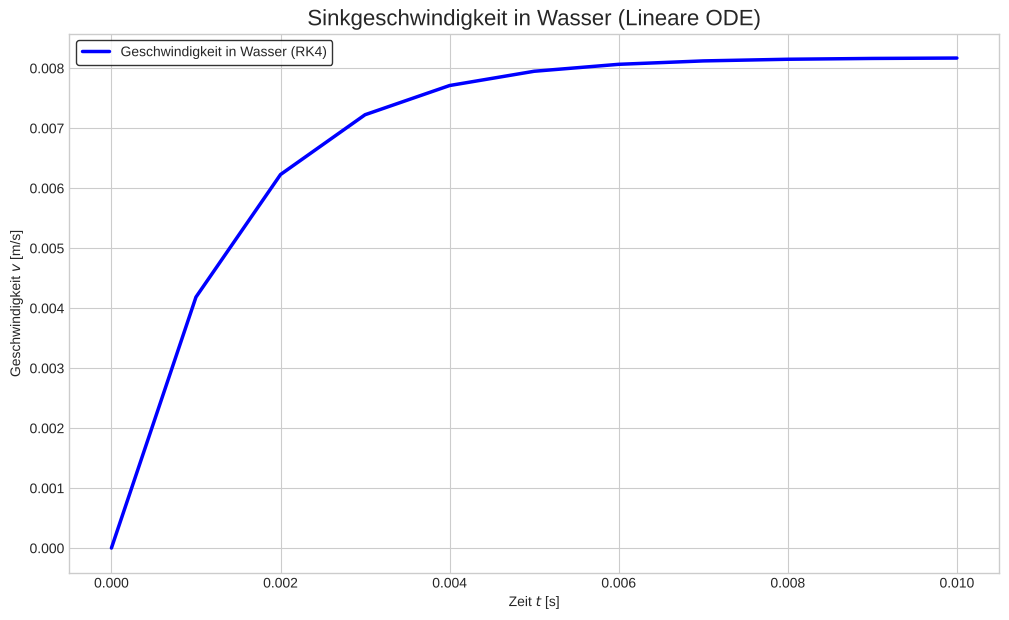

Erreichte Endgeschwindigkeit in Wasser: 0.0082 m/s


In [3]:
# Definition der linearen ODE für das Stokes-Regime
def stokes_ode(t, v):
    term_grav = g * (1 - rho_f_water / rho_p)
    term_drag = (18 * eta_f_water) / (rho_p * d_p**2) * v
    return term_grav - term_drag

# Relaxationszeit des Partikels (zum Vergleich mit dem Zeitschritt)
tau = rho_p * d_p**2 / (18 * eta_f_water)
print(f"Relaxationszeit tau = {tau:.2e} s")

# Lösen der ODE mit der selbst implementierten RK4-Funktion
t_span_water = [0, 0.01]
v0_water = 0.0
dt_water = 0.001  # Zeitschrittweite Δt für die numerische Lösung [s]
t_water_rk4, v_water_rk4 = ##########


# Grafische Darstellung
fig_water, ax_water = plt.subplots(figsize=(12, 7))
ax_water.plot(##########, ##########, 'b-', lw=2.5, label="Geschwindigkeit in Wasser (RK4)")
ax_water.set_title("Sinkgeschwindigkeit in Wasser (Lineare ODE)", fontsize=16)
ax_water.set_xlabel("Zeit $t$ [s]")
ax_water.set_ylabel("Geschwindigkeit $v$ [m/s]")
ax_water.legend(frameon=True, facecolor='white', edgecolor='black', framealpha=0.8)
ax_water.grid(True)
plt.show()

print(f"Erreichte Endgeschwindigkeit in Wasser: {v_water_rk4[-1]:.4f} m/s")

#### 2.3.3 Fall 2: Sinken in Gas (Schiller-Naumann-Widerstand → Nichtlineare ODE)
$$ c_w = \frac{24}{Re_p}\left(1 + 0{,}15\, Re_p^{0{,}687}\right) \qquad (1 < Re_p < 800) $$

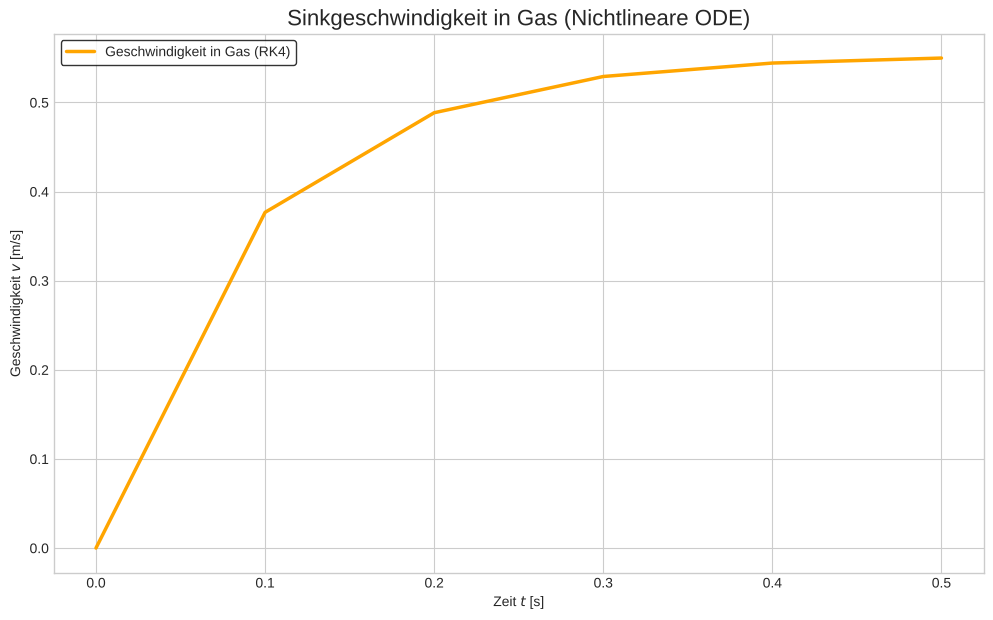

Erreichte Endgeschwindigkeit in Gas: 0.5499 m/s


In [4]:
# Definition der nichtlinearen ODE für das Schiller-Naumann-Regime
def schiller_naumann_ode(t, v):

    # 1. Partikel-Reynolds-Zahl berechnen
    Re_p = ##########

    # 2. Widerstandsbeiwert c_w berechnen
    if Re_p > 800:      # oberhalb des Gültigkeitsbereichs: Newton-Bereich, c_w ≈ 0,44
        c_w = 0.44
    elif Re_p > 0:      # Schiller-Naumann-Korrelation
        c_w = ##########
    else:               # v = 0: noch kein Widerstand (verhindert Division durch null)
        c_w = 0.0

    # 3. dv/dt berechnen (allgemeine ODE-Form)
    term_grav = ##########
    term_drag = ##########
    return term_grav - term_drag

# Lösen der ODE mit der selbst implementierten RK4-Funktion
t_span_gas = [0, 0.5]
v0_gas = 0.0
dt_gas = 0.1  # Zeitschrittweite Δt für die numerische Lösung [s]
t_gas_rk4, v_gas_rk4 = rk4(schiller_naumann_ode, t_span_gas, v0_gas, dt_gas)


# Grafische Darstellung
fig_gas, ax_gas = plt.subplots(figsize=(12, 7))
ax_gas.plot(t_gas_rk4, v_gas_rk4, '-', color='orange', lw=2.5, label="Geschwindigkeit in Gas (RK4)")
ax_gas.set_title("Sinkgeschwindigkeit in Gas (Nichtlineare ODE)", fontsize=16)
ax_gas.set_xlabel("Zeit $t$ [s]")
ax_gas.set_ylabel("Geschwindigkeit $v$ [m/s]")
ax_gas.legend(frameon=True, facecolor='white', edgecolor='black', framealpha=0.8)
ax_gas.grid(True)
plt.show()

print(f"Erreichte Endgeschwindigkeit in Gas: {v_gas_rk4[-1]:.4f} m/s")

### Vergleich der expliziten Verfahren für das Sinken in Wasser

Berechnungen für das Sinken in Wasser abgeschlossen.


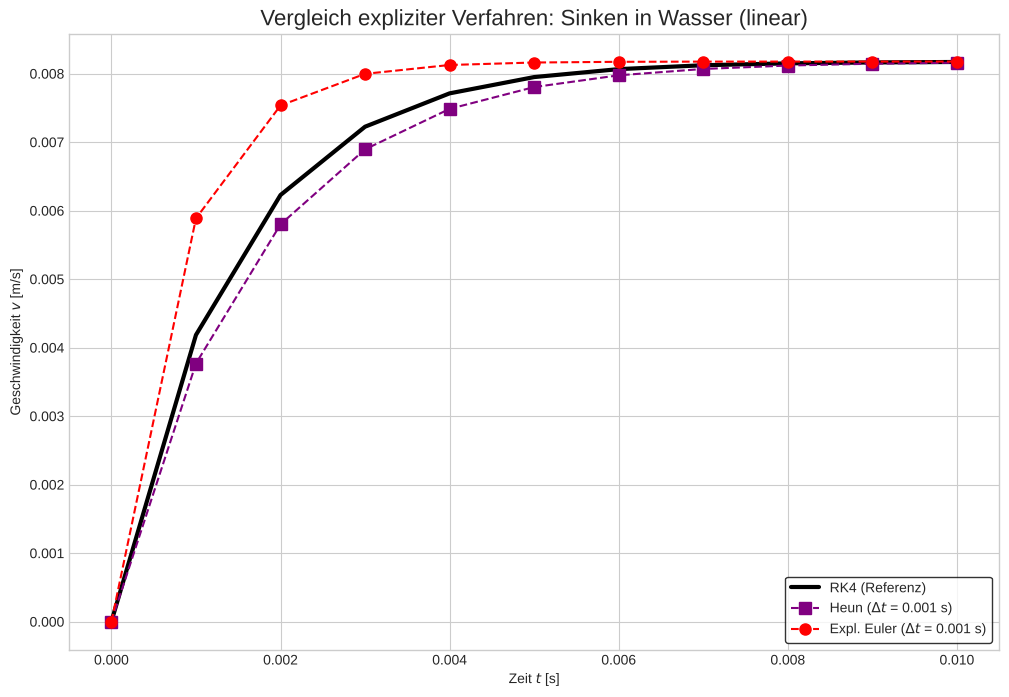

In [5]:
# Simulationseinstellungen für den Fall "Wasser"
t_span_water = [0, 0.01]
v0_water = 0.0
dt_water = 0.001  # Relativ großer Zeitschritt Δt, um Unterschiede sichtbar zu machen

# Berechne die Lösungen mit den drei expliziten Verfahren
t_water_euler, v_water_euler = ##########(##########, t_span_water, v0_water, dt_water)
t_water_heun, v_water_heun = ##########(##########, t_span_water, v0_water, dt_water)
t_water_rk4, v_water_rk4 = ##########(##########, t_span_water, v0_water, dt_water)

print("Berechnungen für das Sinken in Wasser abgeschlossen.")
# --- Code: Grafische Darstellung ---

fig_water_comp, ax_water_comp = plt.subplots(figsize=(12, 8))

# Plot der Ergebnisse
ax_water_comp.plot(t_water_rk4, v_water_rk4, 'k-', lw=3, label='RK4 (Referenz)')
ax_water_comp.plot(t_water_heun, v_water_heun, 's--', color='purple', markersize=8, label=f'Heun ($\\Delta t$ = {dt_water} s)')
ax_water_comp.plot(t_water_euler, v_water_euler, 'o--', color='red', markersize=8, label=f'Expl. Euler ($\\Delta t$ = {dt_water} s)')


ax_water_comp.set_title("Vergleich expliziter Verfahren: Sinken in Wasser (linear)", fontsize=16)
ax_water_comp.set_xlabel("Zeit $t$ [s]")
ax_water_comp.set_ylabel("Geschwindigkeit $v$ [m/s]")
ax_water_comp.legend(frameon=True, facecolor='white', edgecolor='black', framealpha=0.8)
ax_water_comp.grid(True)
plt.show()

### Vergleich der expliziten Verfahren für das Sinken in Gas

Berechnungen für das Sinken in Gas abgeschlossen.


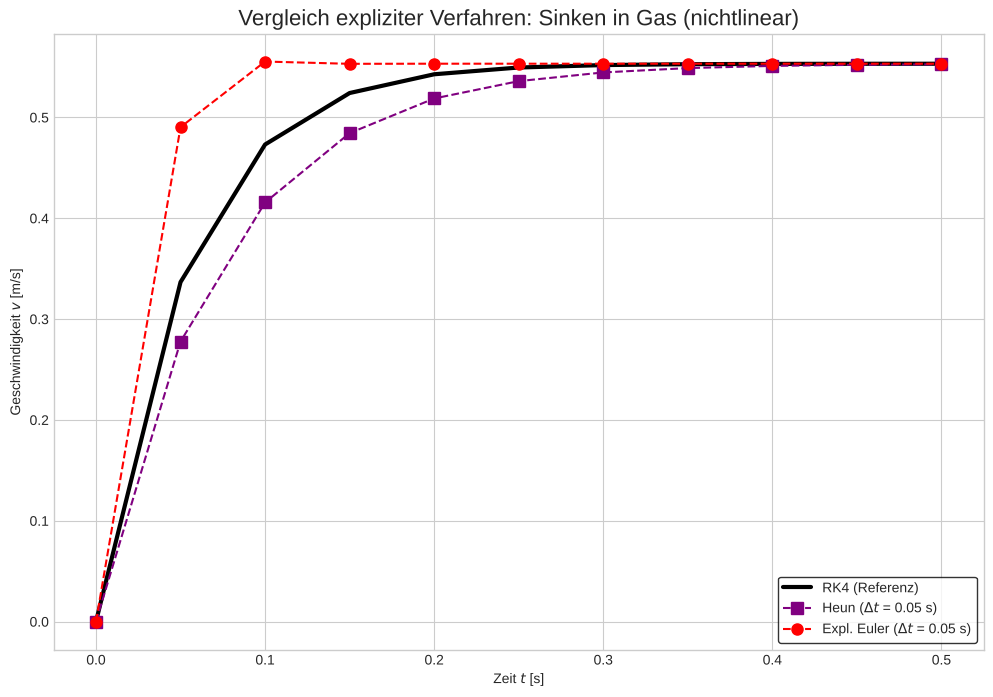

In [6]:
# Simulationseinstellungen für den Fall "Gas"
t_span_gas = [0, 0.5]
v0_gas = 0.0
dt_gas = 0.05  # Großer Zeitschritt Δt, um die Unterschiede bei der Genauigkeit hervorzuheben

# Berechne die Lösungen mit den drei expliziten Verfahren
t_gas_euler, v_gas_euler = ##########(##########, t_span_gas, v0_gas, dt_gas)
t_gas_heun, v_gas_heun = ##########(##########, t_span_gas, v0_gas, dt_gas)
t_gas_rk4, v_gas_rk4 = ##########(##########, t_span_gas, v0_gas, dt_gas)

print("Berechnungen für das Sinken in Gas abgeschlossen.")
# --- Code: Grafische Darstellung ---

fig_gas_comp, ax_gas_comp = plt.subplots(figsize=(12, 8))

# Plot der Ergebnisse
ax_gas_comp.plot(t_gas_rk4, v_gas_rk4, 'k-', lw=3, label='RK4 (Referenz)')
ax_gas_comp.plot(t_gas_heun, v_gas_heun, 's--', color='purple', markersize=8, label=f'Heun ($\\Delta t$ = {dt_gas} s)')
ax_gas_comp.plot(t_gas_euler, v_gas_euler, 'o--', color='red', markersize=8, label=f'Expl. Euler ($\\Delta t$ = {dt_gas} s)')


ax_gas_comp.set_title("Vergleich expliziter Verfahren: Sinken in Gas (nichtlinear)", fontsize=16)
ax_gas_comp.set_xlabel("Zeit $t$ [s]")
ax_gas_comp.set_ylabel("Geschwindigkeit $v$ [m/s]")
ax_gas_comp.legend(frameon=True, facecolor='white', edgecolor='black', framealpha=0.8)
ax_gas_comp.grid(True)
plt.show()